# MCA - Multiple Correspondence Analysis : detect profiles in the population



ACM : Analyse factorielle des correspondances multiples



!!! Compléter les références !!!


In [118]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as stats
import sqlite3 as sql

In [119]:
from fanalysis.ca import CA 
from fanalysis.mca import MCA

In [120]:
### Import a module of custom functions
##  WARNING: The ‘sparql_functions.py’ file must be located 
#   in a folder that is included in the search path
#   recognized by this Jupyter notebook so that
#   the import works correctly

import sys
from importlib import reload


# Add parent directory to the path
sys.path.insert(0, '..')

### If you want to add the parent-parent directory,
sys.path.insert(0, '../..')



In [121]:

import bivariate_library as bl
import correspondence_analysis_library as cal
import cluster_functions as cf


In [101]:
### Use this pnéy to reload the functions if modified
# print(reload(bl))
# print(reload(cal))  

## Import the data and prepare the analysis

In this notebook, we use the data produced with the [bivariate analysis notebook using countries](da3-1_countries_bivariate_analysis.ipynb) and the data collected in the [da5-employer.md](../../documentation/wikidata/data-analysis/da5-employer.md) and [da5-employer.sql](../../documentation/wikidata/data-analysis/da5-employer.sql) files.



In [15]:
csv_address='../da4_data/da4_AFC.csv'
df_p = pd.read_csv(csv_address)
df_p.head(3)

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,CNTR_ID,CNTR_NAME,NAME_ENGL,ISO3_CODE,coded_country,activityYear,periodsActivity
0,http://www.wikidata.org/entity/Q204508,Johann Michael Ackner,1782,male,Sighișoara,POINT (24.791111 46.216945),http://www.wikidata.org/entity/Q193001,1781-1790,8,Eastern Europe,RO,România,Romania,ROU,Central Europe,1827.0,1826-1850
1,http://www.wikidata.org/entity/Q4525913,Stanislas de Chaudoir,1790,male,Makhnivka,POINT (28.676944 49.721944),http://www.wikidata.org/entity/Q2511152,1781-1790,8,Eastern Europe,UA,Україна,Ukraine,UKR,Ukraine,1835.0,1826-1850
2,http://www.wikidata.org/entity/Q1063531,Charles Alfred Stothard,1786,male,London,POINT (-0.1275 51.507222),http://www.wikidata.org/entity/Q84,1781-1790,24,Northern Europe,UK,United Kingdom,United Kingdom,GBR,United Kingdom,1831.0,1826-1850


In [104]:
df_p = df_p.drop(['CNTR_ID', 'CNTR_NAME', 'ISO3_CODE', 'activityYear', 'uriPlace', 'periods', 'FID', 'CNTR_ID'], axis=1)

In [16]:
### Inspect the dataframe and 
# notably if there are missing values
df_p.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4546 entries, 0 to 4545
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   uriPer           4546 non-null   object 
 1   labelPer         4546 non-null   object 
 2   birthYear        4546 non-null   int64  
 3   gender           4546 non-null   object 
 4   labelPlace       4546 non-null   object 
 5   geometry         4546 non-null   object 
 6   uriPlace         4546 non-null   object 
 7   periods          4546 non-null   object 
 8   FID              4546 non-null   int64  
 9   REGION           4546 non-null   object 
 10  CNTR_ID          4546 non-null   object 
 11  CNTR_NAME        4546 non-null   object 
 12  NAME_ENGL        4545 non-null   object 
 13  ISO3_CODE        4545 non-null   object 
 14  coded_country    4545 non-null   object 
 15  activityYear     4545 non-null   float64
 16  periodsActivity  4545 non-null   object 
dtypes: float64(1),

In [17]:
df_p=df_p.rename(columns={'uriPer': 'person_uri'})

In [18]:
df_p.head(2)

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,CNTR_ID,CNTR_NAME,NAME_ENGL,ISO3_CODE,coded_country,activityYear,periodsActivity
0,http://www.wikidata.org/entity/Q204508,Johann Michael Ackner,1782,male,Sighișoara,POINT (24.791111 46.216945),http://www.wikidata.org/entity/Q193001,1781-1790,8,Eastern Europe,RO,România,Romania,ROU,Central Europe,1827.0,1826-1850
1,http://www.wikidata.org/entity/Q4525913,Stanislas de Chaudoir,1790,male,Makhnivka,POINT (28.676944 49.721944),http://www.wikidata.org/entity/Q2511152,1781-1790,8,Eastern Europe,UA,Україна,Ukraine,UKR,Ukraine,1835.0,1826-1850


In [19]:
pd.set_option('display.max_columns', None)
# Reset to default settings if needed later
# pd.reset_option('display.max_columns')

In [21]:
### Import the new qualitative values to be added: occupation and employer class
csv_address='../da5_data/da5-persons-features.csv'
# Explicitly tell pandas which strings to treat as NA (exclude 'NA' from the list)
# By default, pandas treats 'NA', 'N/A', 'NaN', etc. as missing values.
# If you want to override this by specifying a custom list that does NOT include 'NA'.
## df_pfeat = pd.read_csv(csv_address, na_values=['', 'N/A', 'NULL', 'None'])
df_pfeat = pd.read_csv(csv_address)
df_pfeat.head()

,pk_person_features,person_uri,occupation_main,occupation_sec1,education_place
0,3,http://www.wikidata.org/entity/Q1000525,archaeologist,historian,Bolyai University
1,4,http://www.wikidata.org/entity/Q1001016,archaeologist,jeweler,Eötvös Loránd University
2,9,http://www.wikidata.org/entity/Q100152299,archaeologist,university-teacher,Kiel University
3,10,http://www.wikidata.org/entity/Q1001774,archaeologist,university-teacher,Eötvös Loránd University
4,11,http://www.wikidata.org/entity/Q100213,archaeologist,university-teacher,Harvard Divinity School


In [22]:
### Observe the 
df_pfeat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5372 entries, 0 to 5371
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   pk_person_features  5372 non-null   int64 
 1   person_uri          5372 non-null   object
 2   occupation_main     5372 non-null   object
 3   occupation_sec1     5372 non-null   object
 4   education_place     5372 non-null   object
dtypes: int64(1), object(4)
memory usage: 210.0+ KB


In [23]:
## Merge the two dataframes
df_pm = pd.merge(df_p,df_pfeat, on='person_uri')  
# following part was used for inspection
# , how='left')

In [24]:
## The small number depends on the considered countries
df_pm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1713 entries, 0 to 1712
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   person_uri          1713 non-null   object 
 1   labelPer            1713 non-null   object 
 2   birthYear           1713 non-null   int64  
 3   gender              1713 non-null   object 
 4   labelPlace          1713 non-null   object 
 5   geometry            1713 non-null   object 
 6   uriPlace            1713 non-null   object 
 7   periods             1713 non-null   object 
 8   FID                 1713 non-null   int64  
 9   REGION              1713 non-null   object 
 10  CNTR_ID             1713 non-null   object 
 11  CNTR_NAME           1713 non-null   object 
 12  NAME_ENGL           1713 non-null   object 
 13  ISO3_CODE           1713 non-null   object 
 14  coded_country       1713 non-null   object 
 15  activityYear        1713 non-null   float64
 16  period

### Manage secondary occupation

We will have to code a part of the categories because their number is too small, which makes the variable too sparse.

In [36]:
### Group and count: secondary occupation
# We observe some dispersion that requires grouping the categories of the variable
df_count = df_pm.groupby('occupation_sec1').size()
df_count = pd.DataFrame(df_count.sort_values(ascending = False))
df_count.columns=['number']
print(len(df_count))
print(df_count.iloc[:50])



10
                    number
occupation_sec1           
university-teacher     530
other                  333
historian              328
anthropologist         273
art-historian          106
writer                  47
prehistorian            26
politician              25
museologist             24
curator                 21


In [26]:
## We only take the first 19 elements in the list, the more interesting ones
ldf = df_count[df_count.number > 19].index.to_list()
print(ldf)

['university-teacher', 'historian', 'anthropologist', 'art-historian', 'writer', 'prehistorian', 'politician', 'museologist', 'curator']


In [27]:
## prepare the function to code the data
def code_occupation_sec1(occup, ldf):

    """
    codes values according to list
    """

    if occup in ldf:
        output = occup
    else:
        output= 'other'
    return output        

In [28]:
### Code the data
df_pm.occupation_sec1 = df_pm.occupation_sec1.apply(lambda x: code_occupation_sec1(x, ldf))

In [29]:
### Group and count: secondary occupation
# We observe the results of the codind
df_count = df_pm.groupby('occupation_sec1').size()
df_count = pd.DataFrame(df_count.sort_values(ascending = False))
df_count.columns=['number']
print(df_count)


                    number
occupation_sec1           
university-teacher     530
other                  333
historian              328
anthropologist         273
art-historian          106
writer                  47
prehistorian            26
politician              25
museologist             24
curator                 21


In [30]:
df_pm.head(3)

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,CNTR_ID,CNTR_NAME,NAME_ENGL,ISO3_CODE,coded_country,activityYear,periodsActivity,pk_person_features,occupation_main,occupation_sec1,education_place
0,http://www.wikidata.org/entity/Q204508,Johann Michael Ackner,1782,male,Sighișoara,POINT (24.791111 46.216945),http://www.wikidata.org/entity/Q193001,1781-1790,8,Eastern Europe,RO,România,Romania,ROU,Central Europe,1827.0,1826-1850,9029,archaeologist,other,University of Göttingen
1,http://www.wikidata.org/entity/Q529604,Jacques Viger,1787,male,Montreal,POINT (-73.586841 45.503343),http://www.wikidata.org/entity/Q340,1781-1790,23,Northern America,CA,Canada-Canada,Canada,CAN,United States Can.,1832.0,1826-1850,12996,archaeologist,historian,Collège de Montréal
2,http://www.wikidata.org/entity/Q567735,Charles Robert Cockerell,1788,male,London,POINT (-0.1275 51.507222),http://www.wikidata.org/entity/Q84,1781-1790,24,Northern Europe,UK,United Kingdom,United Kingdom,GBR,United Kingdom,1833.0,1826-1850,13896,archaeologist,anthropologist,Westminster School


## Coding the universities

In [35]:
# Showing the places of education
df_ed = df_pm.groupby('education_place').size()
df_ed = pd.DataFrame(df_ed.sort_values(ascending = False))
df_ed.columns=['number']
print(df_ed)

# that is too many to sort and group manually so we'll have a group called other

                                number
education_place                       
École Normale Supérieure            52
University of Vienna                50
Humboldt-Universität zu Berlin      49
Harvard University                  43
Eötvös Loránd University            40
...                                ...
École d'architecture de Lyon         1
École d'administration               1
lycée du Parc                        1
lyceum                               1
collège Notre-Dame de la Paix        1

[551 rows x 1 columns]


In [39]:
## We only take the first 19 elements in the list, the more interesting ones
f_ed = df_ed[df_ed.number > 19].index.to_list()
print(f_ed)

['École Normale Supérieure', 'University of Vienna', 'Humboldt-Universität zu Berlin', 'Harvard University', 'Eötvös Loránd University', 'University of Bonn', 'Saint Petersburg State University', 'École des chartes', 'Leipzig University', 'University of Göttingen', 'Beaux-Arts de Paris', 'Italian School of Archaeology at Athens', 'Uppsala University']


In [58]:
## prepare the function to code the data
def code_edducation(uni, f_ed):

    """
    codes values according to list
    """

    if uni in f_ed:
        output = uni
    else:
        output= 'other_uni'
    return output 

In [59]:
### Code the data
df_pm.education_place = df_pm.education_place.apply(lambda x: code_edducation(x, f_ed))

In [60]:
df_pm.head(3)

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,CNTR_ID,CNTR_NAME,NAME_ENGL,ISO3_CODE,coded_country,activityYear,periodsActivity,pk_person_features,occupation_main,occupation_sec1,education_place
0,http://www.wikidata.org/entity/Q204508,Johann Michael Ackner,1782,male,Sighișoara,POINT (24.791111 46.216945),http://www.wikidata.org/entity/Q193001,1781-1790,8,Eastern Europe,RO,România,Romania,ROU,Central Europe,1827.0,1826-1850,9029,archaeologist,other,University of Göttingen
1,http://www.wikidata.org/entity/Q529604,Jacques Viger,1787,male,Montreal,POINT (-73.586841 45.503343),http://www.wikidata.org/entity/Q340,1781-1790,23,Northern America,CA,Canada-Canada,Canada,CAN,United States Can.,1832.0,1826-1850,12996,archaeologist,historian,other_uni
2,http://www.wikidata.org/entity/Q567735,Charles Robert Cockerell,1788,male,London,POINT (-0.1275 51.507222),http://www.wikidata.org/entity/Q84,1781-1790,24,Northern Europe,UK,United Kingdom,United Kingdom,GBR,United Kingdom,1833.0,1826-1850,13896,archaeologist,anthropologist,other_uni


## MCA

In [64]:
data_cat = df_pm[['gender', 'coded_country', 'occupation_sec1', 'education_place']]
data_cat.head(3)


,gender,coded_country,occupation_sec1,education_place
0,male,Central Europe,other,University of Göttingen
1,male,United States Can.,historian,other_uni
2,male,United Kingdom,anthropologist,other_uni


In [65]:
DActives=data_cat

In [66]:
# We inspect the table that will be analysed
p = DActives.shape[1]
#nombre d'observations
n = DActives.shape[0]
print('Number of variables:', p, ' -- Nomber of individuals (rows):', n)
#codage en 0/1


Number of variables: 4  -- Nomber of individuals (rows): 1713


### Complete disjunctive table 

Sometimes also referred to as a dummy variable matrix or indicator matrix.

In the context of Multiple Correspondence Analysis (MCA), this table is used to transform qualitative (categorical) variables into a quantitative format suitable for analysis. Each category of a qualitative variable becomes a separate binary column (0 or 1), indicating the absence or presence of that category for each individual.

In [67]:
## Complete disjunctive table
X = pd.get_dummies(DActives,prefix='',prefix_sep='')*1
X.head(3)

,female,male,Austria Hungary,Baltic States Fin. Belar.,Belgium Netherl.,Central Europe,Czechia,France,Germany,Italy,Poland,Russian Federation,Scandinavia,Spain Port.,Ukraine,United Kingdom,United States Can.,anthropologist,art-historian,curator,historian,museologist,other,politician,prehistorian,university-teacher,writer,Beaux-Arts de Paris,Eötvös Loránd University,Harvard University,Humboldt-Universität zu Berlin,Italian School of Archaeology at Athens,Leipzig University,Saint Petersburg State University,University of Bonn,University of Göttingen,University of Vienna,Uppsala University,other_uni,École Normale Supérieure,École des chartes
0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0


In [68]:
### Nombre total de modalités, toute variable confondue
M = X.shape[1]
print('Number of categories:', M)
#nombre max de facteurs
Hmax = M-p
print('Maximum number of factors:', Hmax)

Number of categories: 41
Maximum number of factors: 37


In [69]:
Xm = X.copy(deep=True)
#Total sum per row: 
Xm.loc[:,'Total'] = Xm.sum(axis=1)
#Total sum per column: 
Xm.loc['Total',:] = Xm.sum(axis=0)
Xm.tail()

,female,male,Austria Hungary,Baltic States Fin. Belar.,Belgium Netherl.,Central Europe,Czechia,France,Germany,Italy,Poland,Russian Federation,Scandinavia,Spain Port.,Ukraine,United Kingdom,United States Can.,anthropologist,art-historian,curator,historian,museologist,other,politician,prehistorian,university-teacher,writer,Beaux-Arts de Paris,Eötvös Loránd University,Harvard University,Humboldt-Universität zu Berlin,Italian School of Archaeology at Athens,Leipzig University,Saint Petersburg State University,University of Bonn,University of Göttingen,University of Vienna,Uppsala University,other_uni,École Normale Supérieure,École des chartes,Total
1709,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,4.0
1710,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,4.0
1711,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,4.0
1712,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,4.0
Total,134.0,1579.0,74.0,56.0,37.0,96.0,82.0,289.0,200.0,86.0,64.0,150.0,69.0,67.0,62.0,196.0,185.0,273.0,106.0,21.0,328.0,24.0,333.0,25.0,26.0,530.0,47.0,21.0,40.0,43.0,49.0,20.0,22.0,28.0,39.0,22.0,50.0,20.0,1279.0,52.0,28.0,6852.0


## MCA

The Complete disjoint table is created interanlly by the software

In [70]:
acm = MCA(row_labels=DActives.index,var_labels=DActives.columns)
acm.fit(DActives.values)

,n_components,None
,row_labels,"RangeIndex(st...=1713, step=1)"
,var_labels,Index(['gende...type='object')
,stats,True


In [71]:
eig = pd.DataFrame(acm.eig_).transpose()
eig.columns=['contribution','freq','freq_cumulee']

print('Number of factors (approximation tables):', len(eig), '\n')
print(eig.head(), eig.tail())


Number of factors (approximation tables): 37 

   contribution      freq  freq_cumulee
0      0.454960  4.918490      4.918490
1      0.442005  4.778427      9.696917
2      0.423129  4.574364     14.271281
3      0.380787  4.116616     18.387897
4      0.377039  4.076102     22.463999     contribution      freq  freq_cumulee
32      0.123325  1.333242     95.582353
33      0.120600  1.303785     96.886138
34      0.111636  1.206877     98.093015
35      0.099864  1.079611     99.172625
36      0.076532  0.827375    100.000000


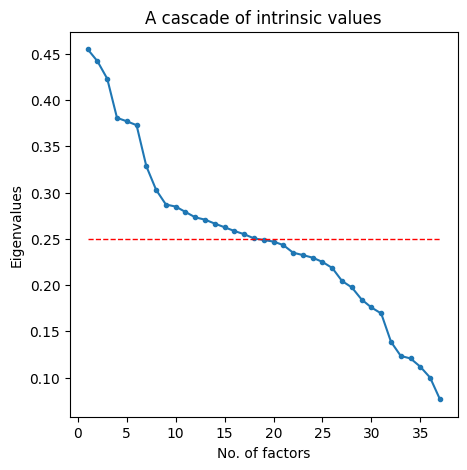

In [72]:
#éboulis des v.p.
fix,ax = plt.subplots(figsize=(5,5))
ax.plot(range(1,Hmax+1),acm.eig_[0],".-")
ax.set_xlabel("No. of factors")
ax.set_ylabel("Eigenvalues")
plt.title("A cascade of intrinsic values")
#seuil - Règle de Kaiser
ax.plot([1,Hmax],[1/p,1/p],"r--",linewidth=1)
plt.show()

*Scree plot*. A graphical representation used to identify an inflection point in a variance curve. The name given to this type of graph derives from the curve’s resemblance to the profile of scree at the foot of a cliff. [DataFranca, Diagramme d'éboulis, 2024](https://datafranca.org/wiki/index.php?title=Diagramme_d%27%C3%A9boulis&oldid=93502)

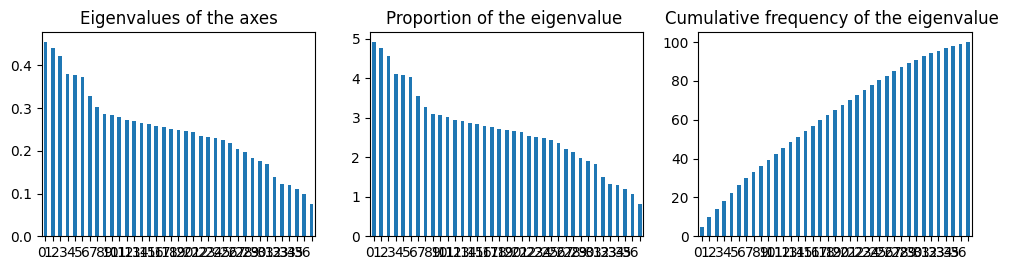

In [73]:

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12,3))

eig.iloc[:,0].plot(kind='bar', ax=axes[0], title='Eigenvalues of the axes')
eig.iloc[:,1].plot(kind='bar', ax=axes[1], title="Proportion of the eigenvalue ")
eig.iloc[:,2].plot(kind='bar', ax=axes[2], title="Cumulative frequency of the eigenvalue ")
# Met les valeurs xticks en vertical
fig.autofmt_xdate(rotation=0)
plt.show()

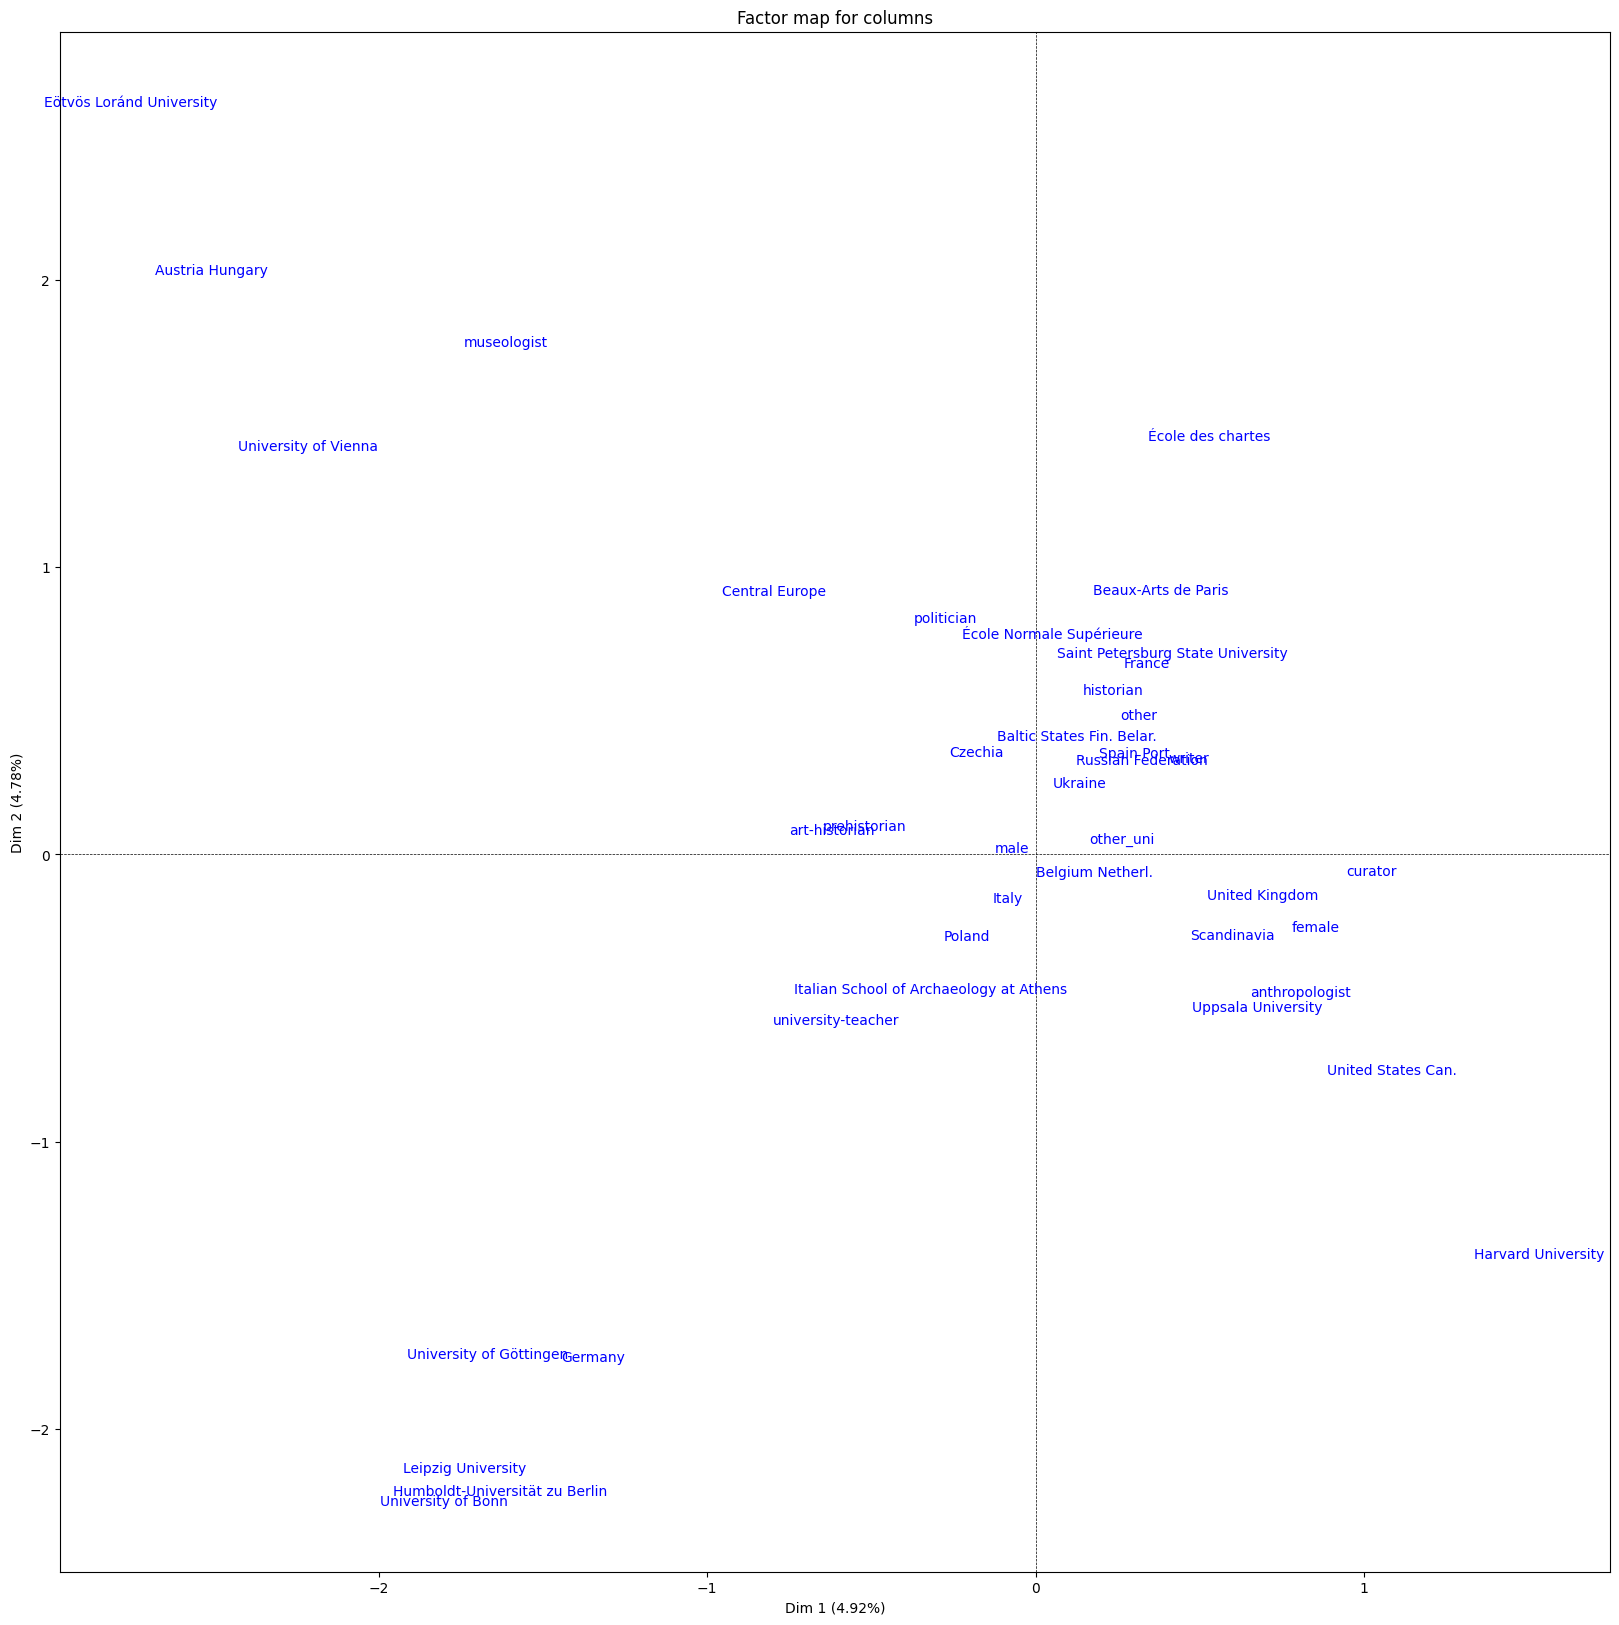

In [74]:
# Mapping des points colonnes
acm.mapping_col(num_x_axis=1, num_y_axis=2, figsize=(20,20))

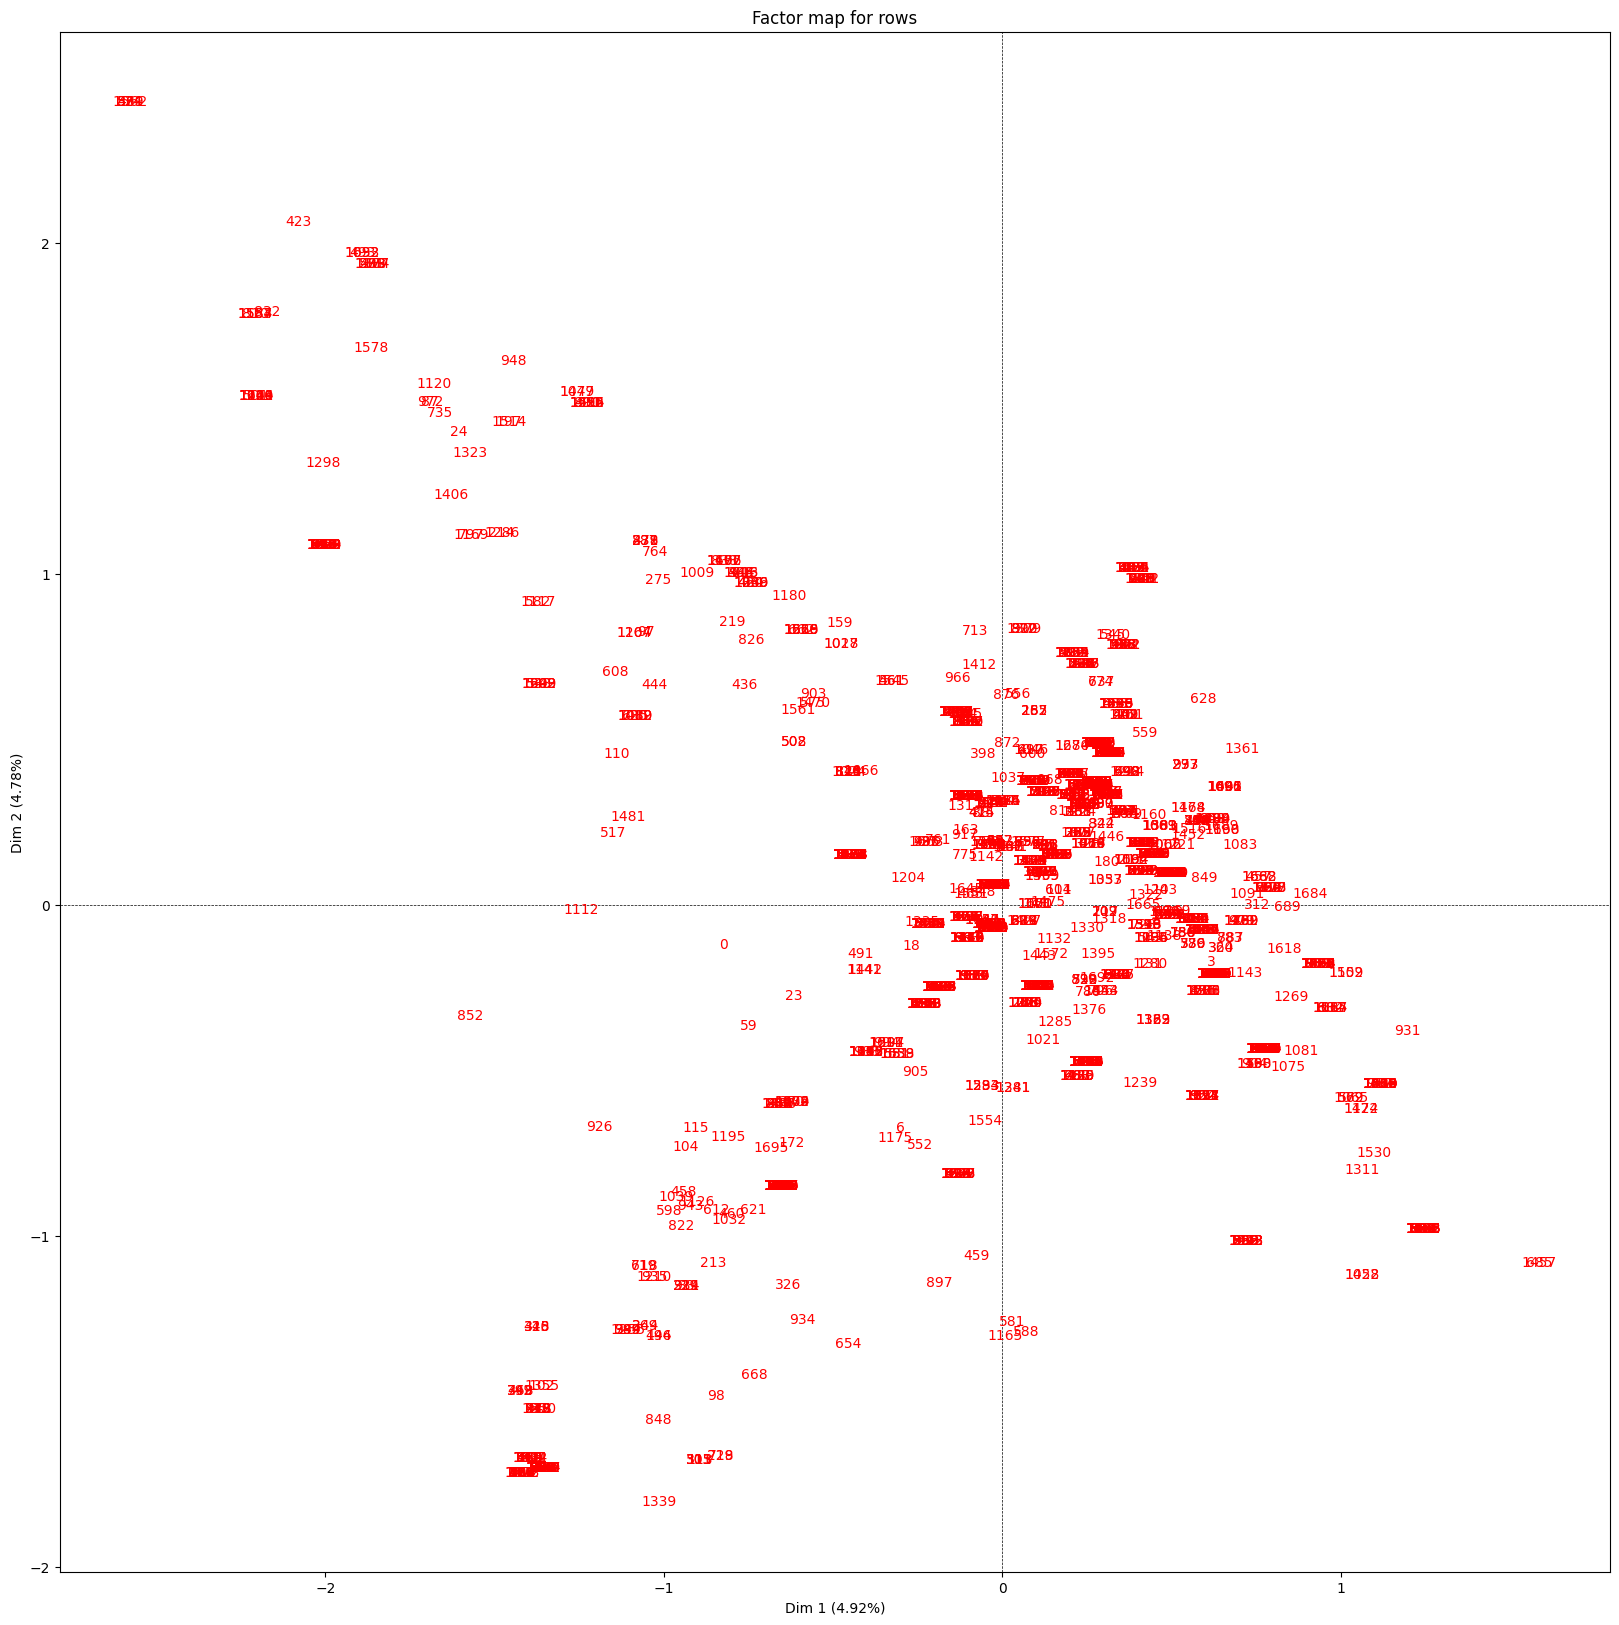

In [75]:
# Mapping des points lignes: individus
acm.mapping_row(num_x_axis=1, num_y_axis=2, figsize=(20,20))

## Représenter les individus

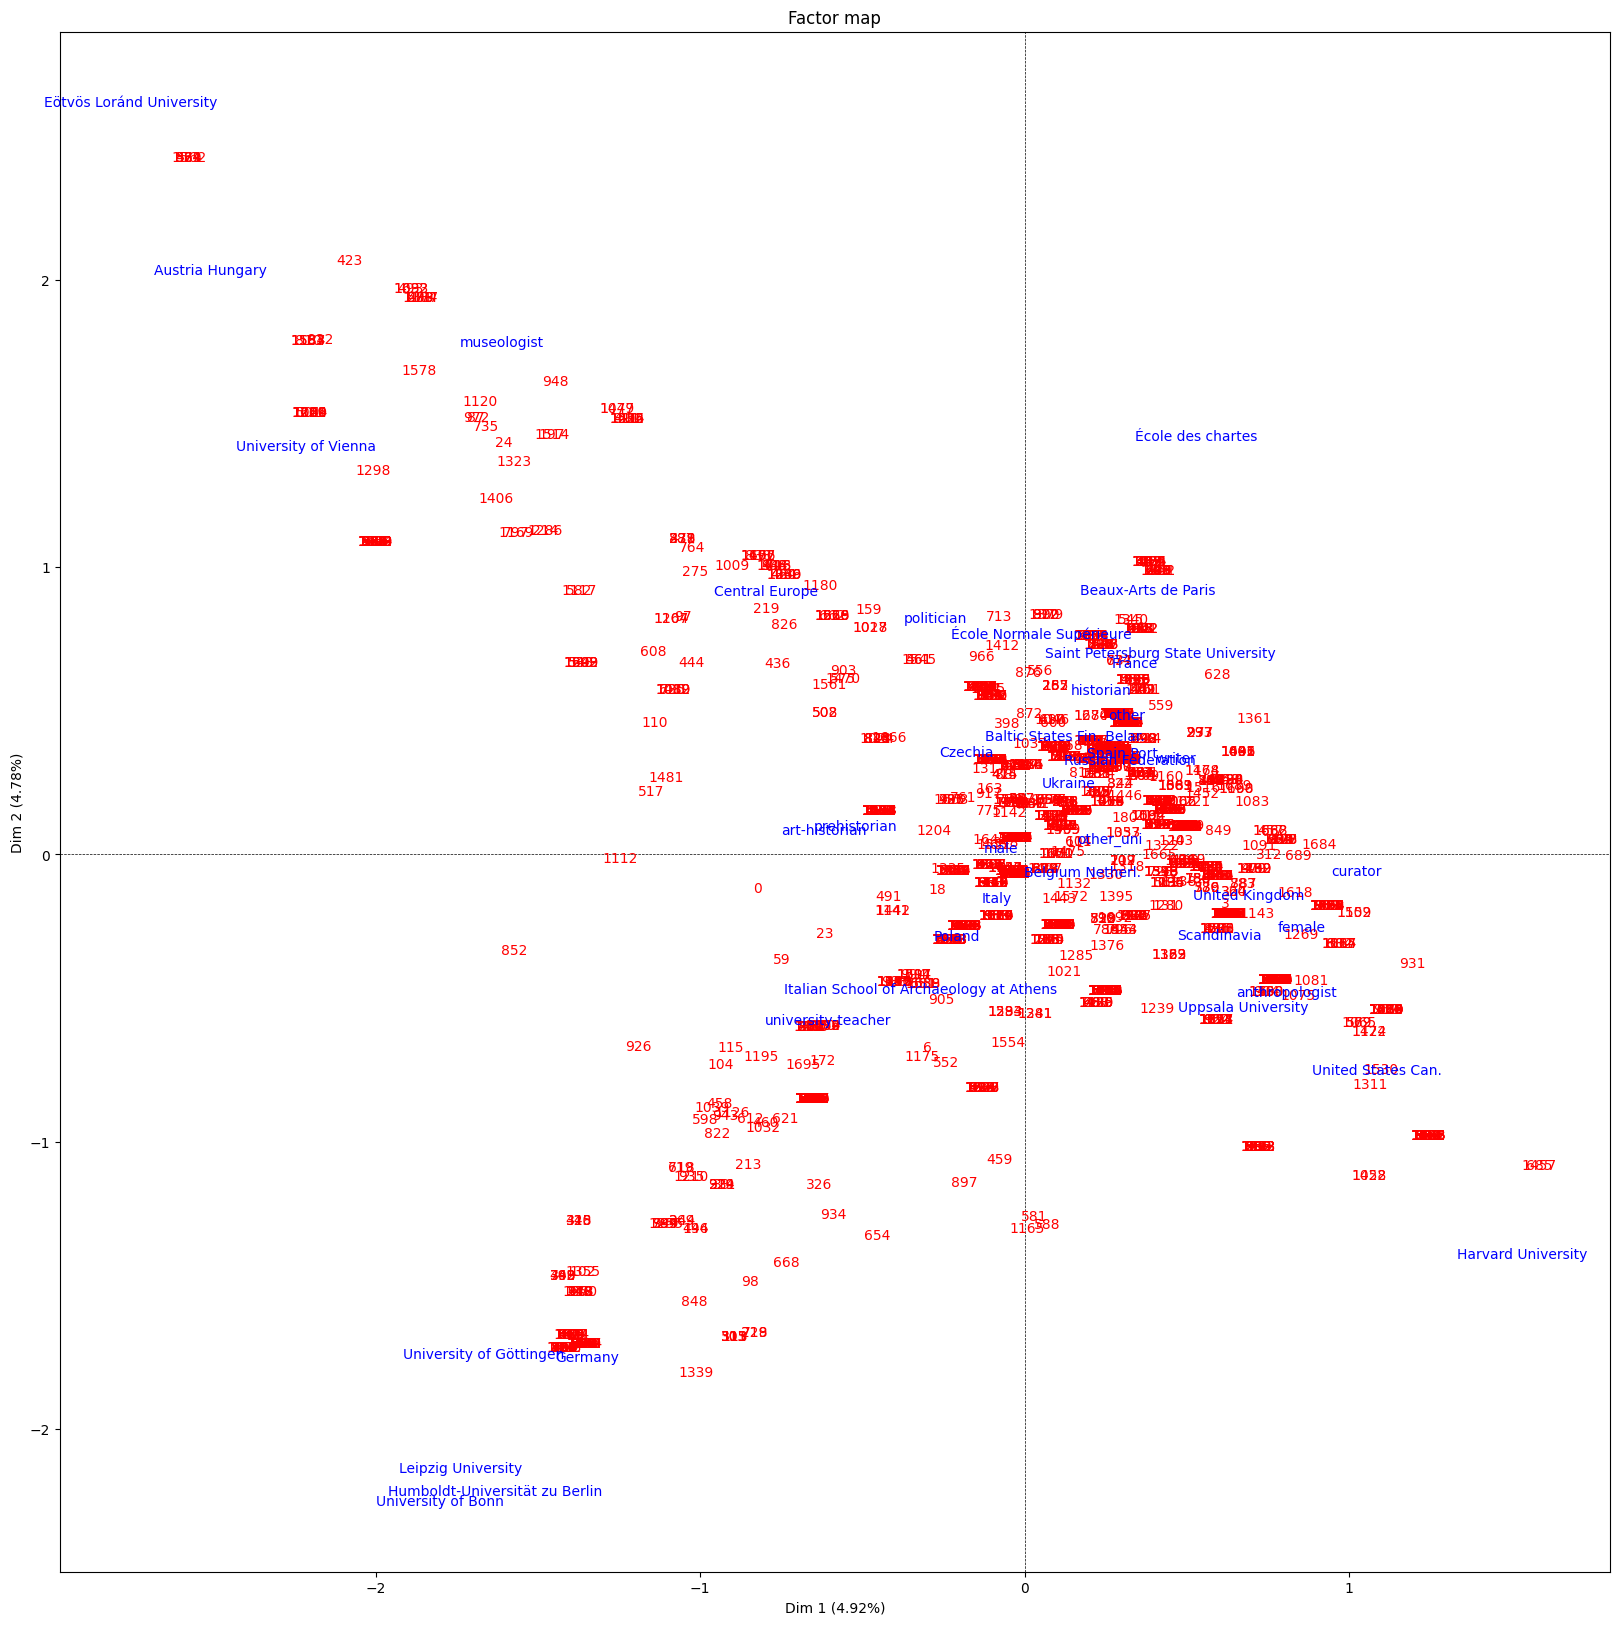

In [76]:
# Simultaneous mapping of row and column points
# The parameters of the mapping method indicate that axes 1 and 2 are represented here
acm.mapping(num_x_axis=1, num_y_axis=2, figsize=(20,20), )

In [81]:
### Inspect individuals
df_pm.loc[[12, 20, 346, 550, 1324]]

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,CNTR_ID,CNTR_NAME,NAME_ENGL,ISO3_CODE,coded_country,activityYear,periodsActivity,pk_person_features,occupation_main,occupation_sec1,education_place
12,http://www.wikidata.org/entity/Q225850,Sven Nilsson,1787,male,Asmundtorp parish,POINT (12.946778 55.886556),http://www.wikidata.org/entity/Q10419868,1781-1790,24,Northern Europe,SE,Sverige,Sweden,SWE,Scandinavia,1832.0,1826-1850,9501,archaeologist,university-teacher,other_uni
20,http://www.wikidata.org/entity/Q1528412,Giuseppe Marchi,1795,male,Tolmezzo,POINT (13.016667 46.4),http://www.wikidata.org/entity/Q53381,1791-1800,19,Southern Europe,IT,Italia,Italy,ITA,Italy,1840.0,1826-1850,7157,archaeologist,anthropologist,other_uni
346,http://www.wikidata.org/entity/Q5625424,Albert Dumont,1842,male,Scey-sur-Saône-et-Saint-Albin,POINT (5.970278 47.666667),http://www.wikidata.org/entity/Q918844,1841-1850,22,Western Europe,FR,France,France,FRA,France,1887.0,1876-1900,13795,archaeologist,art-historian,other_uni
550,http://www.wikidata.org/entity/Q4539987,Chrysanth Yashchurzhinsky,1852,male,Molodets'ke,POINT (30.391945 48.878611),http://www.wikidata.org/entity/Q4300596,1851-1860,8,Eastern Europe,UA,Україна,Ukraine,UKR,Ukraine,1897.0,1876-1900,12330,archaeologist,other,other_uni
1324,http://www.wikidata.org/entity/Q451244,Veselin Beshevliev,1900,male,Sofia,POINT (23.321726 42.697886),http://www.wikidata.org/entity/Q472,1891-1900,8,Eastern Europe,BG,България,Bulgaria,BGR,Central Europe,1945.0,1926-1950,12294,archaeologist,university-teacher,other_uni


## One possible interpretation: how far individuals deviate from the average profile

In [82]:
#Profil individu moyen
ind_moy = np.sum(X.values,axis=0)/(n*p)
print(ind_moy)

[0.01955633 0.23044367 0.01079977 0.0081728  0.00539988 0.01401051
 0.01196731 0.04217747 0.02918856 0.01255108 0.00934034 0.02189142
 0.01007005 0.00977817 0.00904845 0.02860479 0.02699942 0.03984238
 0.01546994 0.0030648  0.04786924 0.00350263 0.04859895 0.00364857
 0.00379451 0.07734968 0.00685931 0.0030648  0.00583771 0.00627554
 0.0071512  0.00291886 0.00321074 0.0040864  0.00569177 0.00321074
 0.00729714 0.00291886 0.18666083 0.00758903 0.0040864 ]


In [83]:
### Add a column showing the chi-squared distance of each individual from the average individual
# for each individual: those further away are rarer
X['dist_org'] = X.apply(lambda x: round(np.sum(1/ind_moy*(x/p-ind_moy)**2),4), raw=True, axis=1)
X['dist_org']

0       24.4841
1        3.2266
2        3.3597
3       36.0019
4        2.6566
         ...   
1708     7.1055
1709    11.5727
1710     6.4143
1711     5.6536
1712     2.5553
Name: dist_org, Length: 1713, dtype: float64

count    1713.000000
mean        9.249998
std         7.332319
min         1.895900
25%         3.359700
50%         6.679200
75%        13.114100
max        43.361400
Name: dist_org, dtype: float64


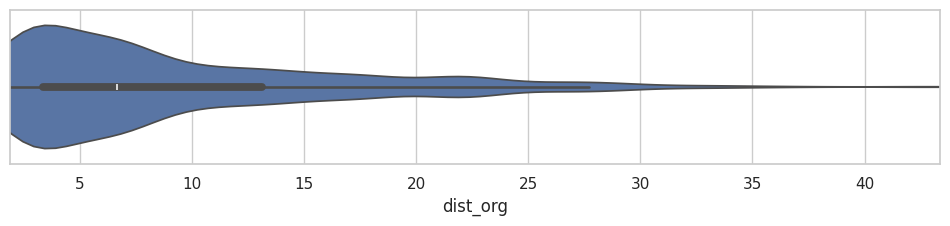

In [84]:

### Distribution of distances from the average individual

sns.set_theme(style="whitegrid",rc={"figure.figsize":(12,2)} )


a = X['dist_org']

print(a.describe())

# ax = sns.boxplot(x=a)
ax = sns.violinplot(x=a)

### Note that values beyond these limits are truncated as they are assumed
ax.set_xlim(left=min(a), right=max(a))

plt.show()

In [95]:
### Individuals close to the average profile
#  and therefore common
i = X[(X.dist_org<10) & (X.dist_org>9)]
print(len(i))
df_pm.loc[i.index][33:35]

40


,person_uri,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,CNTR_ID,CNTR_NAME,NAME_ENGL,ISO3_CODE,coded_country,activityYear,periodsActivity,pk_person_features,occupation_main,occupation_sec1,education_place
1462,http://www.wikidata.org/entity/Q19924050,Jean Bérard,1908,male,Paris,POINT (2.352222 48.856667),http://www.wikidata.org/entity/Q90,1901-1910,22,Western Europe,FR,France,France,FRA,France,1953.0,1951-1975,8898,archaeologist,university-teacher,École Normale Supérieure
1583,http://www.wikidata.org/entity/Q12033416,Libuše Jansová,1904,female,Prague,POINT (14.421389 50.0875),http://www.wikidata.org/entity/Q1085,1901-1910,8,Eastern Europe,CZ,Česká Republika,Czechia,CZE,Czechia,1949.0,1926-1950,4554,archaeologist,other,other_uni


In [106]:
### Individus moyennements distants du profil moyen
sel = X[(X.dist_org>10) & (X.dist_org <9)]   ### [X.dist_org<2.5] proches du prof. m.
print(len(sel))
df_pm.loc[sel.index][10:35]

0


,person_uri,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,CNTR_ID,CNTR_NAME,NAME_ENGL,ISO3_CODE,coded_country,activityYear,periodsActivity,pk_person_features,occupation_main,occupation_sec1,education_place


In [104]:
### Individus très distants du profil moyen
#  donc rares
seld = X[X.dist_org>25]
print(len(seld))
df_pm.loc[seld.index][-5:]

78


,person_uri,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,CNTR_ID,CNTR_NAME,NAME_ENGL,ISO3_CODE,coded_country,activityYear,periodsActivity,pk_person_features,occupation_main,occupation_sec1,education_place
1562,http://www.wikidata.org/entity/Q1317120,András Tasnádi Kubacska,1902,male,Budapest,POINT (19.040833 47.498333),http://www.wikidata.org/entity/Q1781,1901-1910,8,Eastern Europe,HU,Magyarország,Hungary,HUN,Austria Hungary,1947.0,1926-1950,6020,archaeologist,museologist,Eötvös Loránd University
1572,http://www.wikidata.org/entity/Q94772857,Liebetraut Rothert,1909,female,Kwidzyn,POINT (18.930833 53.735833),http://www.wikidata.org/entity/Q326582,1901-1910,8,Eastern Europe,PL,Polska,Poland,POL,Poland,1954.0,1951-1975,16933,archaeologist,prehistorian,other_uni
1593,http://www.wikidata.org/entity/Q1059594,Margherita Guarducci,1902,female,Florence,POINT (11.254167 43.771389),http://www.wikidata.org/entity/Q2044,1901-1910,19,Southern Europe,IT,Italia,Italy,ITA,Italy,1947.0,1926-1950,448,archaeologist,university-teacher,Italian School of Archaeology at Athens
1651,http://www.wikidata.org/entity/Q104713897,Alessandro Prosdocimi,1913,male,Gaiarine,POINT (12.483333 45.883333),http://www.wikidata.org/entity/Q48023,1911-1920,19,Southern Europe,IT,Italia,Italy,ITA,Italy,1958.0,1951-1975,292,archaeologist,other,Italian School of Archaeology at Athens
1684,http://www.wikidata.org/entity/Q20992264,María Braña de Diego,1912,female,Madrid,POINT (-3.703333 40.416944),http://www.wikidata.org/entity/Q2807,1911-1920,19,Southern Europe,ES,España,Spain,ESP,Spain Port.,1957.0,1951-1975,9216,archaeologist,curator,other_uni


## Add the activity periods as supplementary illustrative values

In [107]:
#isoler les variables supplémentaires (ou illustratives)
df_suppl = df_pm[['periodsActivity']]
print(df_suppl.columns)
df_suppl.head(2)

Index(['periodsActivity'], dtype='object')


,periodsActivity
0,1826-1850
1,1826-1850


In [108]:
info_lig = acm.row_topandas()
info_lig[:2]

,row_coord_dim1,row_coord_dim2,row_coord_dim3,row_coord_dim4,row_coord_dim5,row_coord_dim6,row_coord_dim7,row_coord_dim8,row_coord_dim9,row_coord_dim10,row_coord_dim11,row_coord_dim12,row_coord_dim13,row_coord_dim14,row_coord_dim15,row_coord_dim16,row_coord_dim17,row_coord_dim18,row_coord_dim19,row_coord_dim20,row_coord_dim21,row_coord_dim22,row_coord_dim23,row_coord_dim24,row_coord_dim25,row_coord_dim26,row_coord_dim27,row_coord_dim28,row_coord_dim29,row_coord_dim30,row_coord_dim31,row_coord_dim32,row_coord_dim33,row_coord_dim34,row_coord_dim35,row_coord_dim36,row_coord_dim37,row_contrib_dim1,row_contrib_dim2,row_contrib_dim3,row_contrib_dim4,row_contrib_dim5,row_contrib_dim6,row_contrib_dim7,row_contrib_dim8,row_contrib_dim9,row_contrib_dim10,row_contrib_dim11,row_contrib_dim12,row_contrib_dim13,row_contrib_dim14,row_contrib_dim15,row_contrib_dim16,row_contrib_dim17,row_contrib_dim18,row_contrib_dim19,row_contrib_dim20,row_contrib_dim21,row_contrib_dim22,row_contrib_dim23,row_contrib_dim24,row_contrib_dim25,row_contrib_dim26,row_contrib_dim27,row_contrib_dim28,row_contrib_dim29,row_contrib_dim30,row_contrib_dim31,row_contrib_dim32,row_contrib_dim33,row_contrib_dim34,row_contrib_dim35,row_contrib_dim36,row_contrib_dim37,row_cos2_dim1,row_cos2_dim2,row_cos2_dim3,row_cos2_dim4,row_cos2_dim5,row_cos2_dim6,row_cos2_dim7,row_cos2_dim8,row_cos2_dim9,row_cos2_dim10,row_cos2_dim11,row_cos2_dim12,row_cos2_dim13,row_cos2_dim14,row_cos2_dim15,row_cos2_dim16,row_cos2_dim17,row_cos2_dim18,row_cos2_dim19,row_cos2_dim20,row_cos2_dim21,row_cos2_dim22,row_cos2_dim23,row_cos2_dim24,row_cos2_dim25,row_cos2_dim26,row_cos2_dim27,row_cos2_dim28,row_cos2_dim29,row_cos2_dim30,row_cos2_dim31,row_cos2_dim32,row_cos2_dim33,row_cos2_dim34,row_cos2_dim35,row_cos2_dim36,row_cos2_dim37
0,-0.823399,-0.119738,-0.244667,-0.085477,-0.060472,-0.059494,0.028164,-0.986646,1.551598,0.627549,0.441018,0.210288,1.651278,-0.064600,-0.349497,-2.012726,0.065294,-1.250569,0.039992,-1.643163,-0.944152,0.007733,1.186692,0.970976,-1.163216,1.231886,0.411942,-0.515738,-0.359342,0.017003,-0.175795,-0.526046,0.040241,0.152767,-0.366216,-0.975744,0.657473,0.086994,0.001894,0.008259,0.00112,0.000566,0.000554,0.000141,0.187640,0.489638,0.080716,0.040700,0.009450,0.588107,0.000914,0.027170,0.915188,0.000976,0.364552,0.000375,0.638198,0.214017,0.000015,0.353749,0.239765,0.351139,0.405612,0.048479,0.078655,0.040892,0.000096,0.010657,0.116527,0.000767,0.011297,0.070132,0.556551,0.329727,0.027691,0.000586,0.002445,0.000298,0.000149,0.000145,0.000032,0.039759,0.098327,0.016085,0.007944,0.001806,0.111367,0.000170,0.004989,0.165457,0.000174,0.063875,0.000065,0.110275,0.036408,0.000002,0.057516,0.038506,0.055263,0.061981,0.006931,0.010864,0.005274,0.000012,0.001262,0.011302,0.000066,0.000953,0.005478,0.038885,0.017655
1,0.560265,-0.040776,0.343294,-0.064629,-0.394617,0.082617,-0.305885,0.346949,0.445174,-0.308726,0.144427,0.177912,-0.074502,0.084882,0.034130,0.223227,0.094217,-0.041055,0.062427,-0.110986,-0.141799,-0.210279,0.199761,-0.204978,-0.011606,-0.244195,-0.084621,-0.497625,0.108841,-0.218867,-0.068910,0.623638,-0.667564,0.509684,-0.574928,0.015476,-0.159751,0.040277,0.000220,0.016259,0.00064,0.024111,0.001069,0.016632,0.023202,0.040307,0.019535,0.004365,0.006764,0.001197,0.001579,0.000259,0.011257,0.002033,0.000393,0.000915,0.002912,0.004827,0.010987,0.010024,0.010685,0.000035,0.015938,0.002046,0.073227,0.003752,0.015915,0.001638,0.163773,0.210949,0.125747,0.172848,0.000140,0.019466,0.097285,0.000515,0.036525,0.001295,0.048263,0.002115,0.028999,0.037307,0.061421,0.029540,0.006465,0.009810,0.001720,0.002233,0.000361,0.015444,0.002751,0.000522,0.001208,0.003818,0.006232,0.013704,0.012368,0.013022,0.000042,0.018481,0.002219,0.076748,0.003672,0.014846,0.001472,0.120539,0.138117,0.080512,0.102444,0.000074,0.007909


In [109]:
## We merge the two tables.
# Because they have the same order, the coordinates are added to the right individuals
df_supp_lignes = df_suppl.merge(info_lig, left_index=True, right_index=True)
df_supp_lignes.head(2)

,periodsActivity,row_coord_dim1,row_coord_dim2,row_coord_dim3,row_coord_dim4,row_coord_dim5,row_coord_dim6,row_coord_dim7,row_coord_dim8,row_coord_dim9,row_coord_dim10,row_coord_dim11,row_coord_dim12,row_coord_dim13,row_coord_dim14,row_coord_dim15,row_coord_dim16,row_coord_dim17,row_coord_dim18,row_coord_dim19,row_coord_dim20,row_coord_dim21,row_coord_dim22,row_coord_dim23,row_coord_dim24,row_coord_dim25,row_coord_dim26,row_coord_dim27,row_coord_dim28,row_coord_dim29,row_coord_dim30,row_coord_dim31,row_coord_dim32,row_coord_dim33,row_coord_dim34,row_coord_dim35,row_coord_dim36,row_coord_dim37,row_contrib_dim1,row_contrib_dim2,row_contrib_dim3,row_contrib_dim4,row_contrib_dim5,row_contrib_dim6,row_contrib_dim7,row_contrib_dim8,row_contrib_dim9,row_contrib_dim10,row_contrib_dim11,row_contrib_dim12,row_contrib_dim13,row_contrib_dim14,row_contrib_dim15,row_contrib_dim16,row_contrib_dim17,row_contrib_dim18,row_contrib_dim19,row_contrib_dim20,row_contrib_dim21,row_contrib_dim22,row_contrib_dim23,row_contrib_dim24,row_contrib_dim25,row_contrib_dim26,row_contrib_dim27,row_contrib_dim28,row_contrib_dim29,row_contrib_dim30,row_contrib_dim31,row_contrib_dim32,row_contrib_dim33,row_contrib_dim34,row_contrib_dim35,row_contrib_dim36,row_contrib_dim37,row_cos2_dim1,row_cos2_dim2,row_cos2_dim3,row_cos2_dim4,row_cos2_dim5,row_cos2_dim6,row_cos2_dim7,row_cos2_dim8,row_cos2_dim9,row_cos2_dim10,row_cos2_dim11,row_cos2_dim12,row_cos2_dim13,row_cos2_dim14,row_cos2_dim15,row_cos2_dim16,row_cos2_dim17,row_cos2_dim18,row_cos2_dim19,row_cos2_dim20,row_cos2_dim21,row_cos2_dim22,row_cos2_dim23,row_cos2_dim24,row_cos2_dim25,row_cos2_dim26,row_cos2_dim27,row_cos2_dim28,row_cos2_dim29,row_cos2_dim30,row_cos2_dim31,row_cos2_dim32,row_cos2_dim33,row_cos2_dim34,row_cos2_dim35,row_cos2_dim36,row_cos2_dim37
0,1826-1850,-0.823399,-0.119738,-0.244667,-0.085477,-0.060472,-0.059494,0.028164,-0.986646,1.551598,0.627549,0.441018,0.210288,1.651278,-0.064600,-0.349497,-2.012726,0.065294,-1.250569,0.039992,-1.643163,-0.944152,0.007733,1.186692,0.970976,-1.163216,1.231886,0.411942,-0.515738,-0.359342,0.017003,-0.175795,-0.526046,0.040241,0.152767,-0.366216,-0.975744,0.657473,0.086994,0.001894,0.008259,0.00112,0.000566,0.000554,0.000141,0.187640,0.489638,0.080716,0.040700,0.009450,0.588107,0.000914,0.027170,0.915188,0.000976,0.364552,0.000375,0.638198,0.214017,0.000015,0.353749,0.239765,0.351139,0.405612,0.048479,0.078655,0.040892,0.000096,0.010657,0.116527,0.000767,0.011297,0.070132,0.556551,0.329727,0.027691,0.000586,0.002445,0.000298,0.000149,0.000145,0.000032,0.039759,0.098327,0.016085,0.007944,0.001806,0.111367,0.000170,0.004989,0.165457,0.000174,0.063875,0.000065,0.110275,0.036408,0.000002,0.057516,0.038506,0.055263,0.061981,0.006931,0.010864,0.005274,0.000012,0.001262,0.011302,0.000066,0.000953,0.005478,0.038885,0.017655
1,1826-1850,0.560265,-0.040776,0.343294,-0.064629,-0.394617,0.082617,-0.305885,0.346949,0.445174,-0.308726,0.144427,0.177912,-0.074502,0.084882,0.034130,0.223227,0.094217,-0.041055,0.062427,-0.110986,-0.141799,-0.210279,0.199761,-0.204978,-0.011606,-0.244195,-0.084621,-0.497625,0.108841,-0.218867,-0.068910,0.623638,-0.667564,0.509684,-0.574928,0.015476,-0.159751,0.040277,0.000220,0.016259,0.00064,0.024111,0.001069,0.016632,0.023202,0.040307,0.019535,0.004365,0.006764,0.001197,0.001579,0.000259,0.011257,0.002033,0.000393,0.000915,0.002912,0.004827,0.010987,0.010024,0.010685,0.000035,0.015938,0.002046,0.073227,0.003752,0.015915,0.001638,0.163773,0.210949,0.125747,0.172848,0.000140,0.019466,0.097285,0.000515,0.036525,0.001295,0.048263,0.002115,0.028999,0.037307,0.061421,0.029540,0.006465,0.009810,0.001720,0.002233,0.000361,0.015444,0.002751,0.000522,0.001208,0.003818,0.006232,0.013704,0.012368,0.013022,0.000042,0.018481,0.002219,0.076748,0.003672,0.014846,0.001472,0.120539,0.138117,0.080512,0.102444,0.000074,0.007909


### Plot dim1-dim2

In [110]:
#positionnement d'individus
coord = df_supp_lignes[['periodsActivity','row_coord_dim1', 'row_coord_dim2']].copy()
print(len(coord))
coord.head(2)


1713


,periodsActivity,row_coord_dim1,row_coord_dim2
0,1826-1850,-0.823399,-0.119738
1,1826-1850,0.560265,-0.040776


In [111]:

#moyennes conditionnelles - Livre, page 341
coord_fact = pd.pivot_table(data=coord,values=['row_coord_dim1', 'row_coord_dim2'],index='periodsActivity',aggfunc='mean')
coord_fact


,row_coord_dim1,row_coord_dim2
periodsActivity,,
1826-1850,-0.038347,-0.029821
1851-1875,0.030389,0.019462
1876-1900,-0.062504,-0.010397
1901-1925,-0.049615,-0.042323
1926-1950,0.029157,0.038698
1951-1975,0.085341,0.000445


In [112]:

# corrected by the square root of the eigenvalues
# computed barycentres in 2 dimensions (row_coord_dim1 and row_coord_dim2): [:2]
coord_fact = coord_fact/np.sqrt(acm.eig_[0][:2])
print(coord_fact)

                 row_coord_dim1  row_coord_dim2
periodsActivity                                
1826-1850             -0.056851       -0.044855
1851-1875              0.045053        0.029274
1876-1900             -0.092667       -0.015638
1901-1925             -0.073557       -0.063660
1926-1950              0.043227        0.058207
1951-1975              0.126524        0.000669


In [125]:
MCA.mapping_col = cal.custom_mapping_col

AttributeError: module 'correspondence_analysis_library' has no attribute 'custom_mapping_col'

TypeError: Base.mapping_col() got an unexpected keyword argument 'ax'

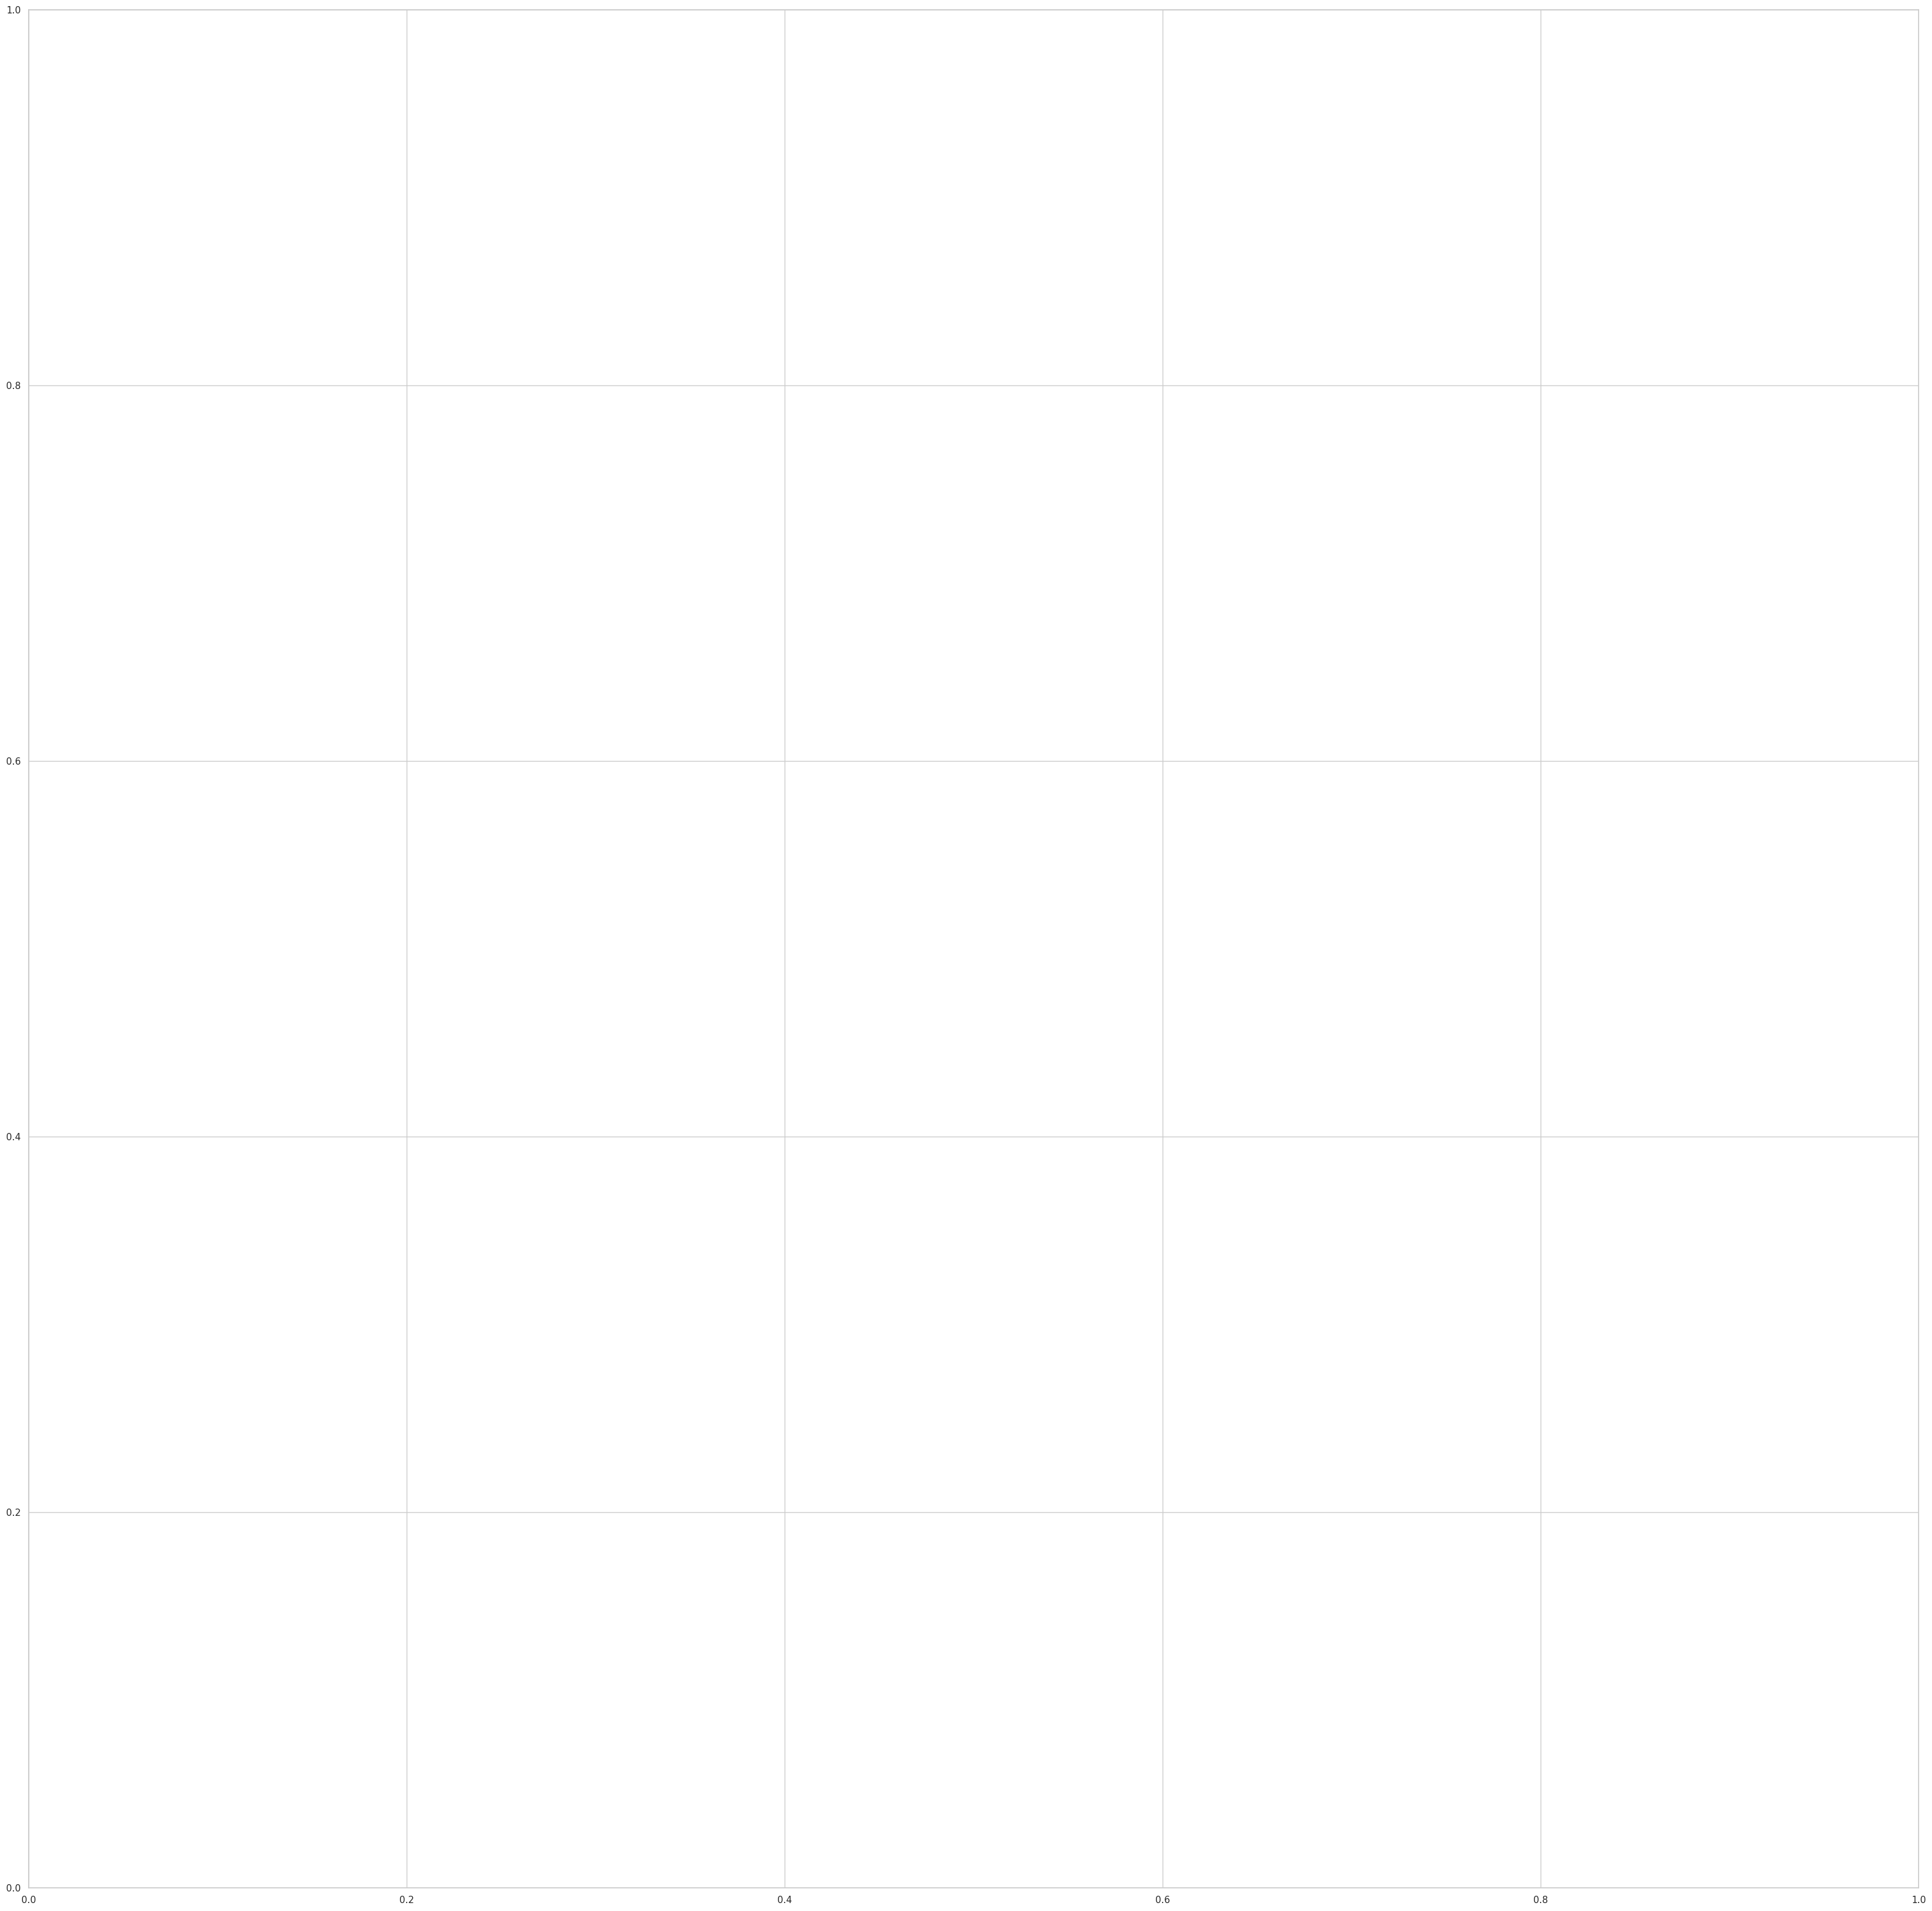

In [126]:
# Create your own figure and axes
fig, ax = plt.subplots(figsize=(40, 40))

# Plot ACM on ax
acm.mapping_col(num_x_axis=1, num_y_axis=2, ax=ax, short_labels=False)

# Add your additional layer

# Add illustrative variable modalities (e.g., Profession)
ax = plt.gca()  # Get current axis
for i in range(coord_fact.shape[0]):
    ax.text(coord_fact.iloc[i, 0], coord_fact.iloc[i, 1], coord_fact.index[i],
            color="darkgreen", fontsize=20, ha='center', va='center')

plt.title("ACM with Illustrative Variables (Profession)")
plt.show()

## Prepare file for cluster analysis

Given that the interpretation of the MCA is quite difficult, given the sparse nature of the variables, we will test the [K-means clustering method](da5-MCA-clusters.ipynb) on the results of the MCA in order to detect significant profiles.

We therefore export here the coded and prepared data to a [dedicated CSV file](da_data/da5-MCA-clusters.csv).

In [127]:
df_pm.head(3)

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,CNTR_ID,CNTR_NAME,NAME_ENGL,ISO3_CODE,coded_country,activityYear,periodsActivity,pk_person_features,occupation_main,occupation_sec1,education_place
0,http://www.wikidata.org/entity/Q204508,Johann Michael Ackner,1782,male,Sighișoara,POINT (24.791111 46.216945),http://www.wikidata.org/entity/Q193001,1781-1790,8,Eastern Europe,RO,România,Romania,ROU,Central Europe,1827.0,1826-1850,9029,archaeologist,other,University of Göttingen
1,http://www.wikidata.org/entity/Q529604,Jacques Viger,1787,male,Montreal,POINT (-73.586841 45.503343),http://www.wikidata.org/entity/Q340,1781-1790,23,Northern America,CA,Canada-Canada,Canada,CAN,United States Can.,1832.0,1826-1850,12996,archaeologist,historian,other_uni
2,http://www.wikidata.org/entity/Q567735,Charles Robert Cockerell,1788,male,London,POINT (-0.1275 51.507222),http://www.wikidata.org/entity/Q84,1781-1790,24,Northern Europe,UK,United Kingdom,United Kingdom,GBR,United Kingdom,1833.0,1826-1850,13896,archaeologist,anthropologist,other_uni


In [128]:
file_address='../da5_data/da5-MCA-clusters.csv'
df_pm.to_csv(file_address, index=False)

## Split the generations and analyse significant ones

In [129]:
activity_period='1876-1900'
df_pm[df_pm.periodsActivity==activity_period].head(3)

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,CNTR_ID,CNTR_NAME,NAME_ENGL,ISO3_CODE,coded_country,activityYear,periodsActivity,pk_person_features,occupation_main,occupation_sec1,education_place
258,http://www.wikidata.org/entity/Q1733509,Karl Zangemeister,1837,male,Hallungen,POINT (10.333056 51.133056),http://www.wikidata.org/entity/Q634874,1831-1840,22,Western Europe,DE,Deutschland,Germany,DEU,Germany,1882.0,1876-1900,8239,archaeologist,university-teacher,Humboldt-Universität zu Berlin
259,http://www.wikidata.org/entity/Q15129866,Henry Williamson Haynes,1831,male,Bangor,POINT (-68.7675 44.803056),http://www.wikidata.org/entity/Q327012,1831-1840,23,Northern America,US,United States,United States,USA,United States Can.,1876.0,1876-1900,7049,archaeologist,university-teacher,Harvard University
260,http://www.wikidata.org/entity/Q3620334,Antonio Zannoni,1833,male,Faenza,POINT (11.883333 44.285556),http://www.wikidata.org/entity/Q52981,1831-1840,19,Southern Europe,IT,Italia,Italy,ITA,Italy,1878.0,1876-1900,11460,archaeologist,other,other_uni


## MCA

In [132]:
data_cat = df_pm[df_pm.periodsActivity==activity_period][['gender', 'coded_country', 'occupation_sec1', 'education_place']]
data_cat.head(3)


,gender,coded_country,occupation_sec1,education_place
258,male,Germany,university-teacher,Humboldt-Universität zu Berlin
259,male,United States Can.,university-teacher,Harvard University
260,male,Italy,other,other_uni


In [133]:
DActives=data_cat

In [134]:
acm = MCA(row_labels=DActives.index,var_labels=DActives.columns)
acm.fit(DActives.values)

,n_components,None
,row_labels,"Index([258, 2...', length=287)"
,var_labels,Index(['gende...type='object')
,stats,True


In [135]:
eig = pd.DataFrame(acm.eig_).transpose()
eig.columns=['contribution','freq','freq_cumulee']

print('Number of factors (approximation tables):', len(eig), '\n')
print(eig.head(), eig.tail())


Number of factors (approximation tables): 36 

   contribution      freq  freq_cumulee
0      0.503234  5.591494      5.591494
1      0.488273  5.425256     11.016750
2      0.439369  4.881883     15.898633
3      0.397581  4.417568     20.316201
4      0.384968  4.277419     24.593620     contribution      freq  freq_cumulee
31      0.119825  1.331393     95.962737
32      0.112908  1.254533     97.217270
33      0.099725  1.108055     98.325324
34      0.084953  0.943924     99.269248
35      0.065768  0.730752    100.000000


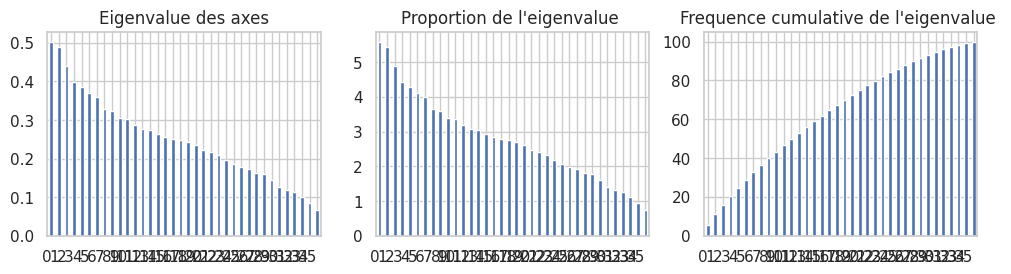

In [136]:

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12,3))

eig.iloc[:,0].plot(kind='bar', ax=axes[0], title='Eigenvalue des axes')
eig.iloc[:,1].plot(kind='bar', ax=axes[1], title="Proportion de l'eigenvalue ")
eig.iloc[:,2].plot(kind='bar', ax=axes[2], title="Frequence cumulative de l'eigenvalue ")
# Met les valeurs xticks en vertical
fig.autofmt_xdate(rotation=0)
plt.show()

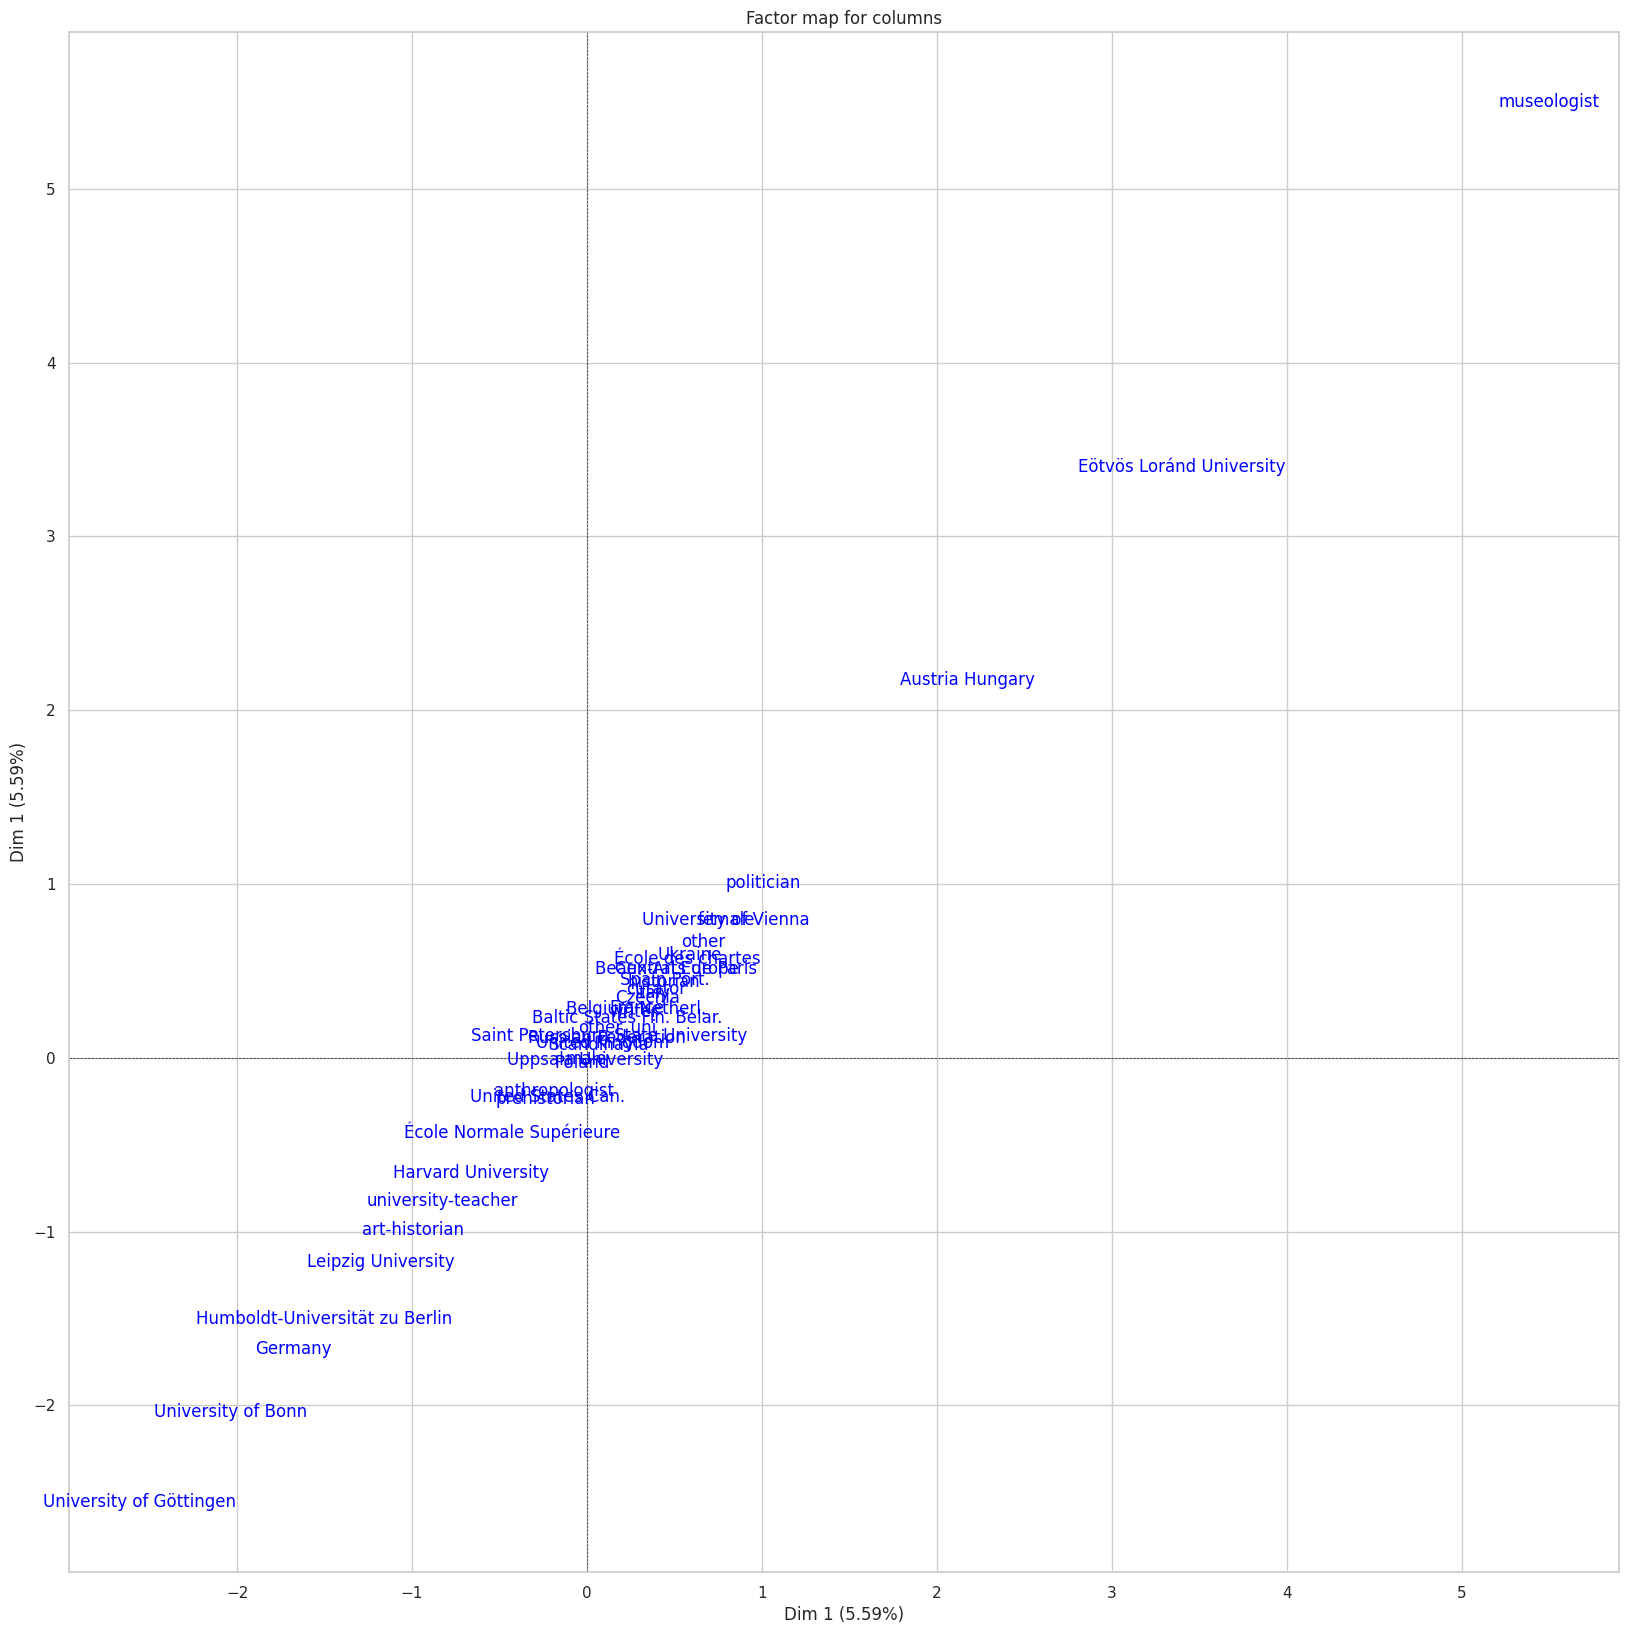

In [137]:
# Mapping des points colonnes
acm.mapping_col(num_x_axis=1, num_y_axis=1, figsize=(20,20))

## Représenter les individus

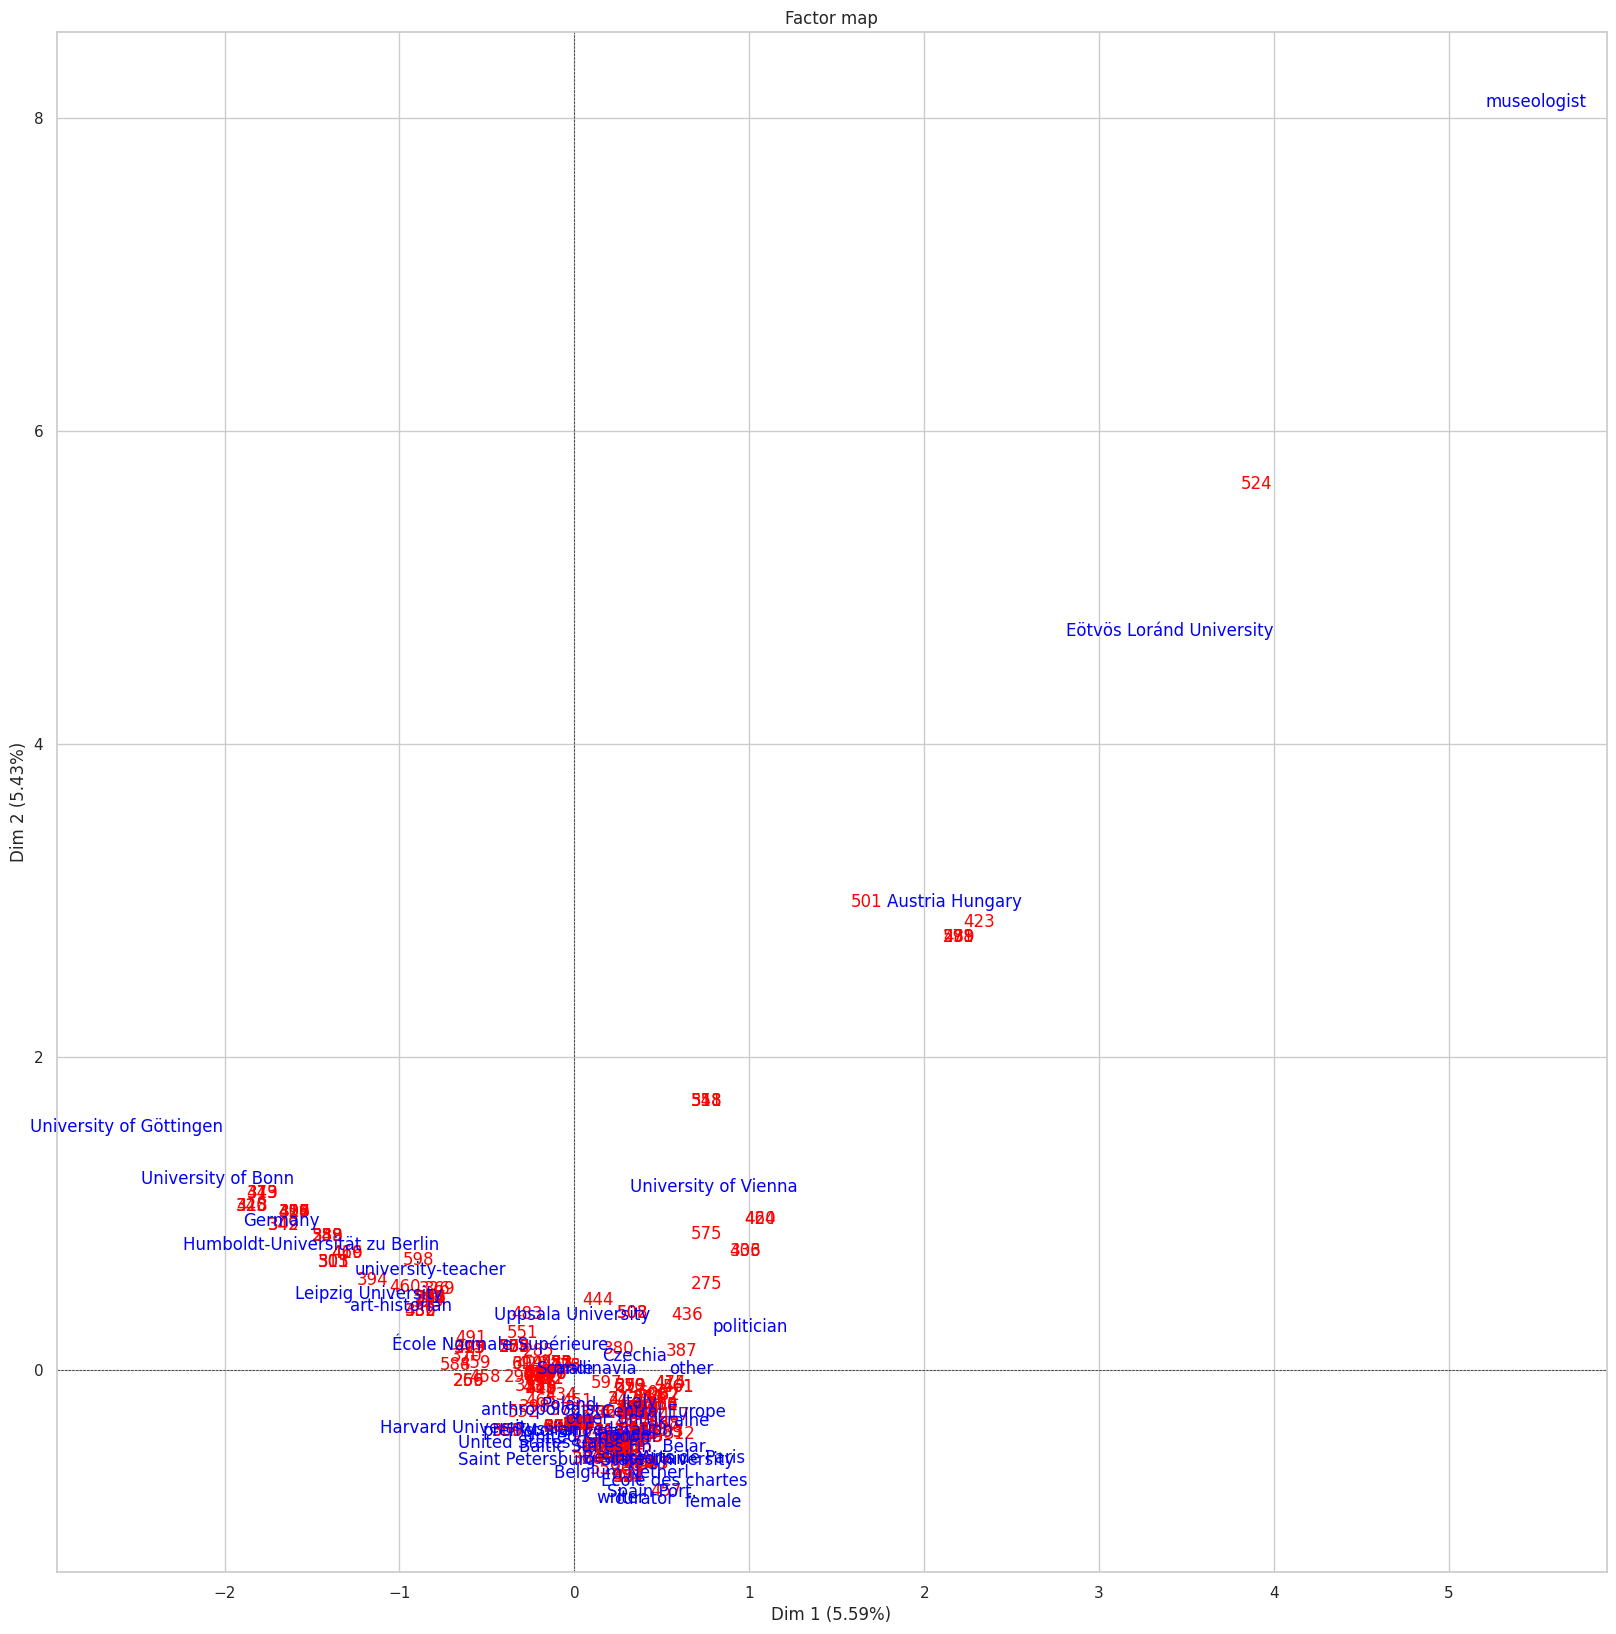

In [138]:
# Mapping simultané des points lignes et colonnes
# Les paramètres de la méthode mapping indiquent que ce sont les axes 1 et 2 qui sont ici représentés
acm.mapping(num_x_axis=1, num_y_axis=2, figsize=(20,20), )

In [139]:
### Inspect individuals
df_pm.loc[[394, 797, 424, 473]]

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,CNTR_ID,CNTR_NAME,NAME_ENGL,ISO3_CODE,coded_country,activityYear,periodsActivity,pk_person_features,occupation_main,occupation_sec1,education_place
394,http://www.wikidata.org/entity/Q21588389,Ernst Schulze,1842,male,Gotha,POINT (10.718333 50.948889),http://www.wikidata.org/entity/Q6986,1841-1850,22,Western Europe,DE,Deutschland,Germany,DEU,Germany,1887.0,1876-1900,9375,archaeologist,historian,University of Bonn
797,http://www.wikidata.org/entity/Q1122505,Bálint Kuzsinszky,1864,male,Subotica,POINT (19.665327 46.100206),http://www.wikidata.org/entity/Q170287,1861-1870,19,Southern Europe,RS,Србија,Serbia,SRB,Central Europe,1909.0,1901-1925,1968,archaeologist,university-teacher,Eötvös Loránd University
424,http://www.wikidata.org/entity/Q71255,Ludwig von Sybel,1846,male,Marburg,POINT (8.766667 50.816667),http://www.wikidata.org/entity/Q3869,1841-1850,22,Western Europe,DE,Deutschland,Germany,DEU,Germany,1891.0,1876-1900,15580,archaeologist,university-teacher,University of Bonn
473,http://www.wikidata.org/entity/Q72507,Adalbert Bezzenberger,1851,male,Kassel,POINT (9.497917 51.315778),http://www.wikidata.org/entity/Q2865,1851-1860,22,Western Europe,DE,Deutschland,Germany,DEU,Germany,1896.0,1876-1900,15662,archaeologist,university-teacher,University of Göttingen
